#### Regression Model - Applying and Interpreting Statistical Tests to Analyze Property Occupancy Rates

- This project analyzes a housing dataset to identify the key drivers of property occupancy rates and quantify how each variable influences occupancy, both positively and negatively.

- The workflow follows a structured data science approach grounded in Data Science and statistical modeling:

- It begins with Exploratory Data Analysis (EDA) to understand data structure, distributions, and potential quality issues. This is followed by correlation analysis to explore relationships between features and detect initial patterns.

- Next, multiple Linear Regression models are developed to estimate the impact of explanatory variables on occupancy rates. During model building, data preprocessing steps are applied, including standardization and the treatment of multicollinearity to improve model reliability.

- Several models are tested and compared, with the final selection based on statistical validity and performance. The chosen model is then evaluated against key regression assumptions to ensure robustness and interpretability.

- The project concludes by interpreting the final model outputs, highlighting the most influential variables affecting occupancy rates and translating statistical results into actionable insights.

**Which factors most influence property occupancy rates?**

In [1]:
# Data wrangling
import numpy as np
import pandas as pd

# Data Viz
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Modeling
import pylab
import scipy
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.regression.linear_model as smf
import statsmodels.stats.api as sms
from scipy.stats import pearsonr
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.compat import lzip

# Data splitting
import sklearn
from sklearn.model_selection import train_test_split

# Data normalization
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

## Loading the Data and Defining the Target Variable

In [2]:
# Loading the Data

FILE_ID = "1Aheu3KTVMrX0sP6loJ8fX3DfkATsiFpb"

url = f"https://drive.google.com/uc?id={FILE_ID}"

df = pd.read_csv(url)


In [3]:
df.head()

,avg_rooms_per_household,avg_house_age,crime_rate,land_ratio,business_ratio,river_proximity,pollution_rate,distance_to_center,accessibility_index,property_tax_rate,teacher_ratio,avg_energy_consumption,homelessness_rate,occupancy_rate
0,6.575,65.2,0.00634,18.0,2.31,0,0.538,4.0900,1,296,15.3,396.90,4.98,24.0
1,6.421,78.9,0.02731,0.0,7.07,0,0.469,4.9671,2,242,17.8,396.90,9.14,21.6
2,7.185,61.1,0.02729,0.0,7.07,0,0.469,4.9671,2,242,17.8,392.83,4.03,34.7
3,6.998,45.8,0.03237,0.0,2.18,0,0.458,6.0622,3,222,18.7,394.63,2.94,33.4
4,7.147,54.2,0.06905,0.0,2.18,0,0.458,6.0622,3,222,18.7,396.90,5.33,36.2


The housing occupancy rate (variable *occupancy_rate*) is the target variable, and the remaining variables are the independent variables, based on which we will analyze the occupancy rate of houses in neighborhoods of a given city.

First, we will check which predictor variables should be used.

In [4]:
# Create a copy of the data (We'll use that later)

df2 = df.copy()

## Exploratory Data Analysis

In [5]:
df.shape

(500, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avg_rooms_per_household  500 non-null    float64
 1   avg_house_age            500 non-null    float64
 2   crime_rate               500 non-null    float64
 3   land_ratio               500 non-null    float64
 4   business_ratio           500 non-null    float64
 5   river_proximity          500 non-null    int64  
 6   pollution_rate           500 non-null    float64
 7   distance_to_center       500 non-null    float64
 8   accessibility_index      500 non-null    int64  
 9   property_tax_rate        500 non-null    int64  
 10  teacher_ratio            500 non-null    float64
 11  avg_energy_consumption   500 non-null    float64
 12  homelessness_rate        500 non-null    float64
 13  occupancy_rate           500 non-null    float64
dtypes: float64(11), int64(3)
m

Analysis:

- There are a total of 500 non-null observations in each column. This indicates that there are no missing values in the dataset.

- Each column in this dataset is numeric in nature.

In [7]:
# Statistical summary

df.describe()

,avg_rooms_per_household,avg_house_age,crime_rate,land_ratio,business_ratio,river_proximity,pollution_rate,distance_to_center,accessibility_index,property_tax_rate,teacher_ratio,avg_energy_consumption,homelessness_rate,occupancy_rate
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,6.282970,68.424600,3.655786,11.500000,11.131740,0.070000,0.554451,3.811932,9.642000,409.624000,18.428600,356.208040,12.698740,22.568000
std,0.705421,28.272145,8.644375,23.428739,6.900712,0.255403,0.116550,2.112591,8.715604,168.998579,2.162553,91.741874,7.164928,9.235707
min,3.561000,2.900000,0.006340,0.000000,0.460000,0.000000,0.385000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,5.883000,44.225000,0.082598,0.000000,5.130000,0.000000,0.448750,2.087875,4.000000,281.000000,17.225000,375.085000,6.990000,17.075000
50%,6.208500,77.150000,0.266005,0.000000,9.125000,0.000000,0.538000,3.267450,5.000000,330.000000,19.000000,391.305000,11.430000,21.200000
75%,6.620500,94.100000,3.694070,12.500000,18.100000,0.000000,0.624000,5.214600,24.000000,666.000000,20.200000,396.157500,17.092500,25.000000
max,8.780000,100.000000,88.976200,100.000000,27.740000,1.000000,0.871000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


Analysis:

- There is an average of approximately 6.28 rooms per dwelling (avg_rooms_per_household).

- There is a high variation in the crime rate variable (crime_rate), as we can see that the lowest crime rate is 0.006, while the highest is 88.97. These are likely outlier values, as they differ significantly from the median and even the 75th percentile.

- The same observation applies to the land_ratio variable.

Before performing the modeling, it is important to check the univariate distribution of the variables, and we will take this opportunity to interpret the data dictionary.

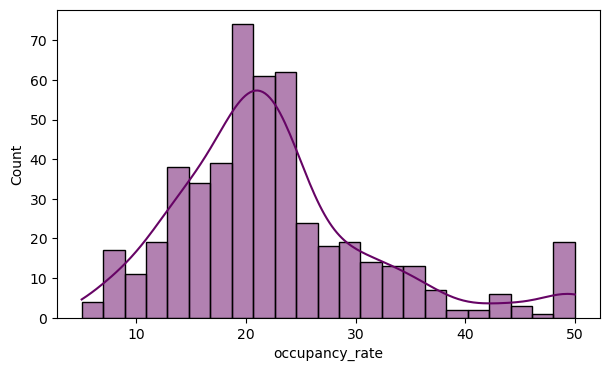

In [8]:
# Histogram plot

plt.figure(figsize = (7, 4))
sns.histplot(data = df, x = df.occupancy_rate, kde = True, color = '#660465')
plt.show()

Analysis:

- The dependent variable appears to be slightly right-skewed.

Since the dependent variable is slightly skewed, we will apply a logarithmic transformation to the **occupancy_rate** column and examine the distribution of the transformed variable. Why? To reduce distortion in the data caused by outliers. The goal of this transformation is to better analyze and understand the underlying patterns in the data.

Next, we will assess the skewness of all variables.

In [9]:
df.skew(axis = 0)

avg_rooms_per_household    0.408139
avg_house_age             -0.584415
crime_rate                 5.194110
land_ratio                 2.205864
business_ratio             0.295577
river_proximity            3.380756
pollution_rate             0.731641
distance_to_center         0.993597
accessibility_index        0.991658
property_tax_rate          0.652944
teacher_ratio             -0.793662
avg_energy_consumption    -2.868339
homelessness_rate          0.893201
occupancy_rate             1.099558
dtype: float64

A skewness value greater than 1 or less than −1 indicates a highly skewed distribution. Values between 0.5 and 1, or between −0.5 and −1, indicate moderate skewness. Values within the range of −0.5 to 0.5 suggest that the distribution is approximately symmetric.

In [10]:
# Transformação de log
df['occupancy_rate_log'] = np.log(df['occupancy_rate'])

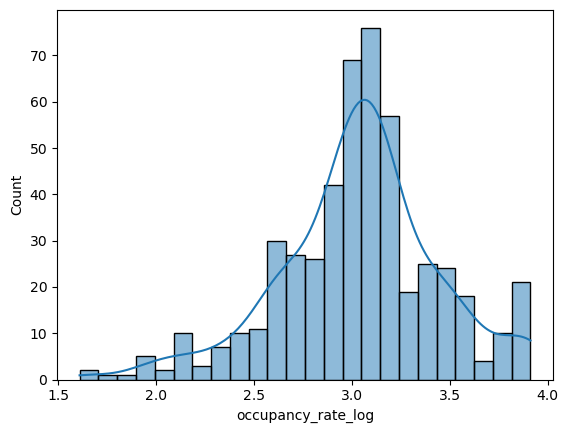

In [11]:
sns.histplot(data = df, x = 'occupancy_rate_log', kde = True);

In [12]:
df.skew(axis = 0)

avg_rooms_per_household    0.408139
avg_house_age             -0.584415
crime_rate                 5.194110
land_ratio                 2.205864
business_ratio             0.295577
river_proximity            3.380756
pollution_rate             0.731641
distance_to_center         0.993597
accessibility_index        0.991658
property_tax_rate          0.652944
teacher_ratio             -0.793662
avg_energy_consumption    -2.868339
homelessness_rate          0.893201
occupancy_rate             1.099558
occupancy_rate_log        -0.332872
dtype: float64

In [13]:
df.head()

,avg_rooms_per_household,avg_house_age,crime_rate,land_ratio,business_ratio,river_proximity,pollution_rate,distance_to_center,accessibility_index,property_tax_rate,teacher_ratio,avg_energy_consumption,homelessness_rate,occupancy_rate,occupancy_rate_log
0,6.575,65.2,0.00634,18.0,2.31,0,0.538,4.0900,1,296,15.3,396.90,4.98,24.0,3.178054
1,6.421,78.9,0.02731,0.0,7.07,0,0.469,4.9671,2,242,17.8,396.90,9.14,21.6,3.072693
2,7.185,61.1,0.02729,0.0,7.07,0,0.469,4.9671,2,242,17.8,392.83,4.03,34.7,3.546740
3,6.998,45.8,0.03237,0.0,2.18,0,0.458,6.0622,3,222,18.7,394.63,2.94,33.4,3.508556
4,7.147,54.2,0.06905,0.0,2.18,0,0.458,6.0622,3,222,18.7,396.90,5.33,36.2,3.589059


Analysis:

- The skewness has been reduced. The dependent variable now appears to be moderately skewed.

- The log-transformed variable (**occupancy_rate_log**) appears to have an approximately normal distribution with minimal skewness, and therefore we can proceed.

Before building the linear regression model, it is important to examine the bivariate relationships between the variables. We will assess this using a heatmap and scatter plots.

## Bivariate Analysis

Let’s examine the correlation using a heatmap. Correlation is a coefficient that measures the relationship between variables and ranges from -1 to +1, where:

A value of -1 indicates a strong negative correlation.
A value of +1 indicates a strong positive correlation.
A value of 0 indicates no correlation.

**Notes**:

We aim for a high correlation between the predictor variables and the target variable, and a low correlation among the predictor variables themselves.
High correlation between predictor variables (positive or negative) indicates a multicollinearity issue and must be addressed.

In [14]:
# Correlation Matrix

df.corr()

,avg_rooms_per_household,avg_house_age,crime_rate,land_ratio,business_ratio,river_proximity,pollution_rate,distance_to_center,accessibility_index,property_tax_rate,teacher_ratio,avg_energy_consumption,homelessness_rate,occupancy_rate,occupancy_rate_log
avg_rooms_per_household,1.000000,-0.243044,-0.218919,0.314221,-0.393012,0.092122,-0.303151,0.208031,-0.208559,-0.291159,-0.362163,0.127517,-0.613654,0.696424,0.632340
avg_house_age,-0.243044,1.000000,0.355852,-0.568654,0.645526,0.088155,0.731859,-0.747426,0.463883,0.512673,0.258119,-0.276578,0.608452,-0.376758,-0.454326
crime_rate,-0.218919,0.355852,1.000000,-0.203363,0.407351,-0.057316,0.422339,-0.384391,0.624880,0.581835,0.297472,-0.383776,0.454628,-0.390960,-0.530713
land_ratio,0.314221,-0.568654,-0.203363,1.000000,-0.534292,-0.044375,-0.516414,0.663235,-0.319191,-0.320072,-0.388901,0.178462,-0.417814,0.359733,0.363476
business_ratio,-0.393012,0.645526,0.407351,-0.534292,1.000000,0.063174,0.763810,-0.709502,0.599156,0.724065,0.384794,-0.357710,0.606354,-0.484606,-0.542907
river_proximity,0.092122,0.088155,-0.057316,-0.044375,0.063174,1.000000,0.091835,-0.101685,-0.010326,-0.037972,-0.119013,0.050259,-0.055847,0.174606,0.158163
pollution_rate,-0.303151,0.731859,0.422339,-0.516414,0.763810,0.091835,1.000000,-0.770068,0.616414,0.671652,0.188255,-0.381440,0.593524,-0.427432,-0.511366
distance_to_center,0.208031,-0.747426,-0.384391,0.663235,-0.709502,-0.101685,-0.770068,1.000000,-0.505664,-0.543241,-0.226258,0.296059,-0.504135,0.248688,0.343079
accessibility_index,-0.208559,0.463883,0.624880,-0.319191,0.599156,-0.010326,0.616414,-0.505664,1.000000,0.909742,0.482377,-0.442594,0.485830,-0.387305,-0.487378
property_tax_rate,-0.291159,0.512673,0.581835,-0.320072,0.724065,-0.037972,0.671652,-0.543241,0.909742,1.000000,0.475243,-0.440226,0.541711,-0.473117,-0.565867


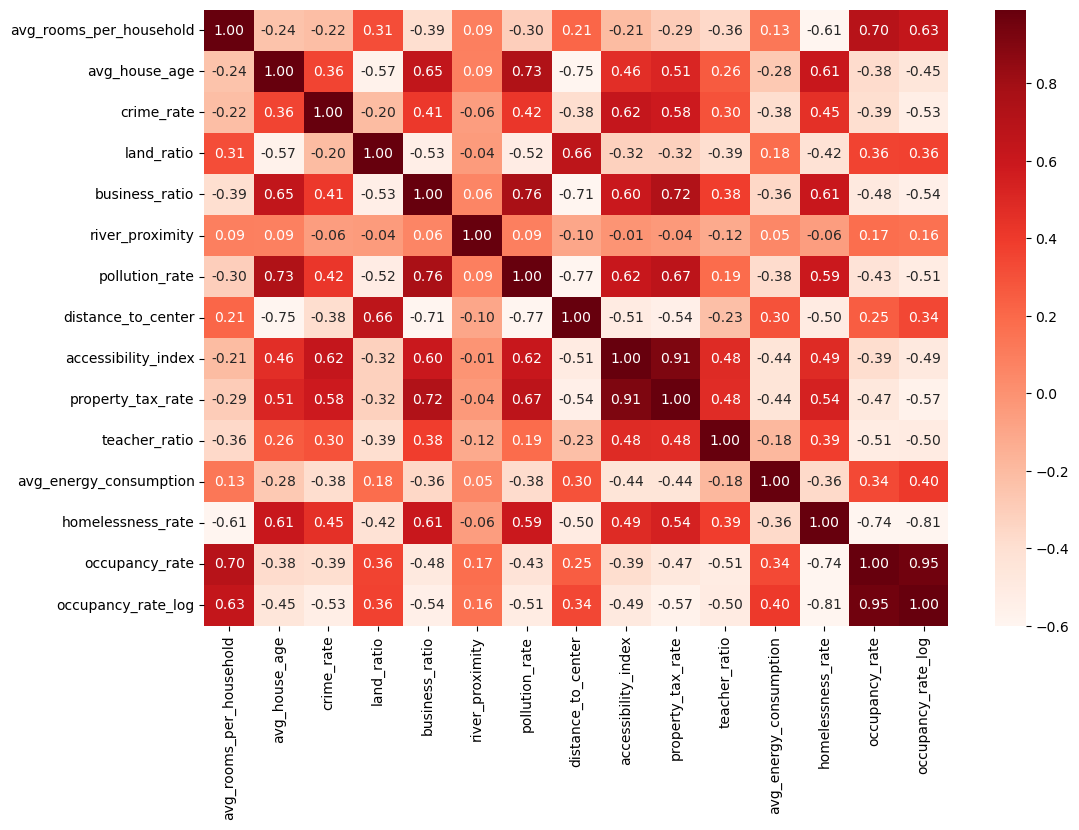

In [15]:
# Fig size

plt.figure(figsize = (12,8))

# Heatmap

# We highlight correlations between 0.59 and 0.99, regardless of sign.

sns.heatmap(df.corr(), annot = True, fmt = '.2f', cmap = 'Reds', vmax = .99, vmin = -0.60)
plt.show()

Analysis:

- We observe a significant correlation between **pollution_rate** and **business_ratio**.

- The variable pollution_rate also shows a strong positive correlation with **avg_house_age**, as well as a significant negative correlation with **distance_to_center**.

- The variable **business_ratio** has a strong correlation with **property_tax_rate**.

- **occupancy_rate** shows a strong correlation with **avg_rooms_per_household**, and also a significant negative correlation with **homelessness_rate**.

- We analyze all correlations between 0.59 and 0.99.

Let’s take a closer look at the variables with the highest correlation.

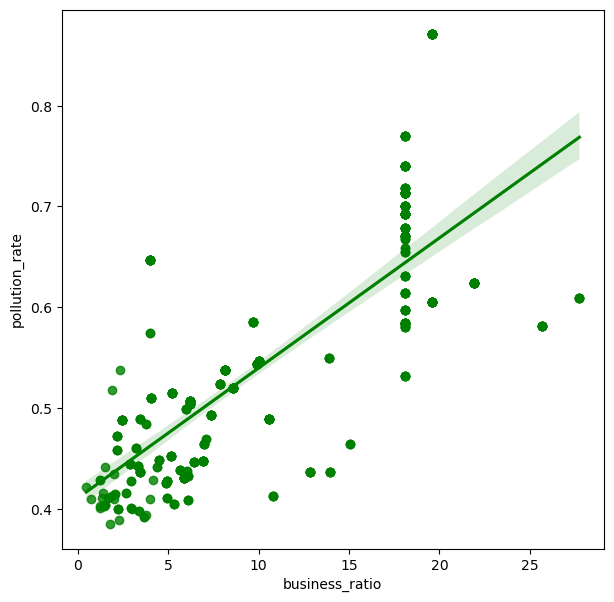

In [16]:
# Scatter Plot 1
plt.figure(figsize = (7, 7))
sns.regplot(x = 'business_ratio', y = 'pollution_rate', data = df, color = 'green') 
plt.show()

In [17]:
# Correlation Coefficient

print('The correlation between the variables is:', pearsonr(df['business_ratio'], 
                                                     df['pollution_rate'])[0])

The correlation between the variables is: 0.763810435078394


Analysis:

- **Positive Correlation:** The pollution rate increases in neighborhoods with a higher proportion of businesses.

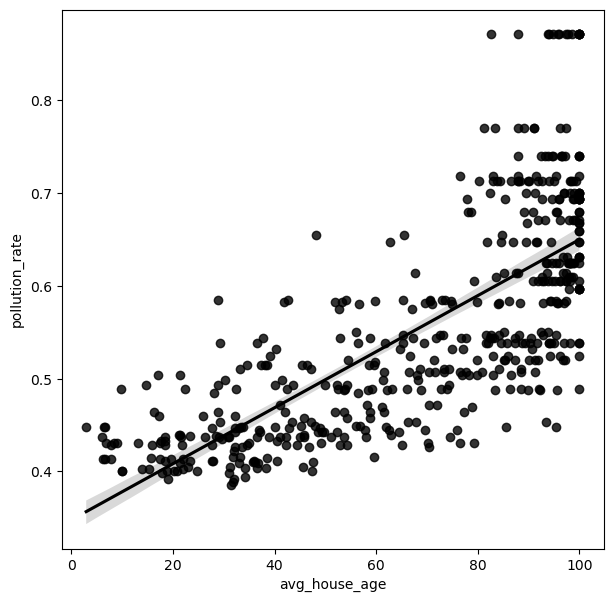

In [18]:
# Scatter Plot 2
plt.figure(figsize = (7, 7))
sns.regplot(x = 'avg_house_age', y = 'pollution_rate', data = df, color = 'black') 
plt.show()

In [19]:
# Correlation Coefficient

print('The correlation between the variables is:', pearsonr(df['avg_house_age'], 
                                                     df['pollution_rate'])[0])

The correlation between the variables is: 0.7318586310142243


Analysis:

- **Positive Correlation:** The pollution rate increases in neighborhoods with older residential buildings (built a long time ago).

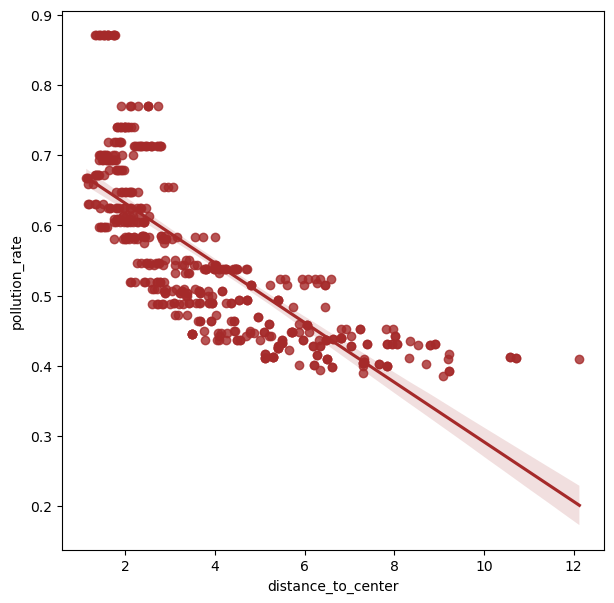

In [20]:
# Scatter Plot 3
plt.figure(figsize = (7, 7))
sns.regplot(x = 'distance_to_center', y = 'pollution_rate', data = df, color = 'brown') 
plt.show()

In [21]:
# Correlation Coefficient

print('The correlation between the variables is:', pearsonr(df['distance_to_center'], 
                                                     df['pollution_rate'])[0])

The correlation between the variables is: -0.7700682232177496


Analysis:

- **Negative Correlation:** The pollution rate decreases in neighborhoods as the distance to the city center increases.

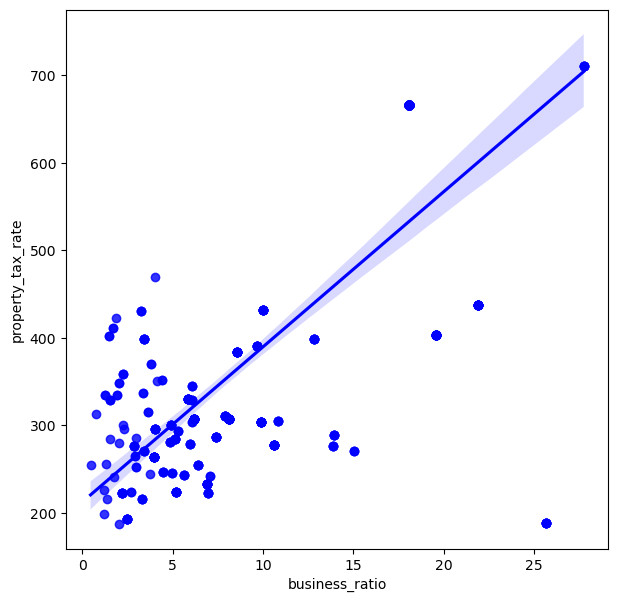

In [22]:
# Scatter Plot 4

plt.figure(figsize = (7, 7))
sns.regplot(x = 'business_ratio', y = 'property_tax_rate', data = df, color = 'blue') 
plt.show()

In [23]:
# Correlation Coeficient

print('The correlation between the variables is:', pearsonr(df['business_ratio'], 
                                                     df['property_tax_rate'])[0])

The correlation between the variables is: 0.7240653150756319


Analysis:

- **Positive Correlation:** Taxes increase as the proportion of businesses in a neighborhood rises. This may be due to both variables being related to a third variable.

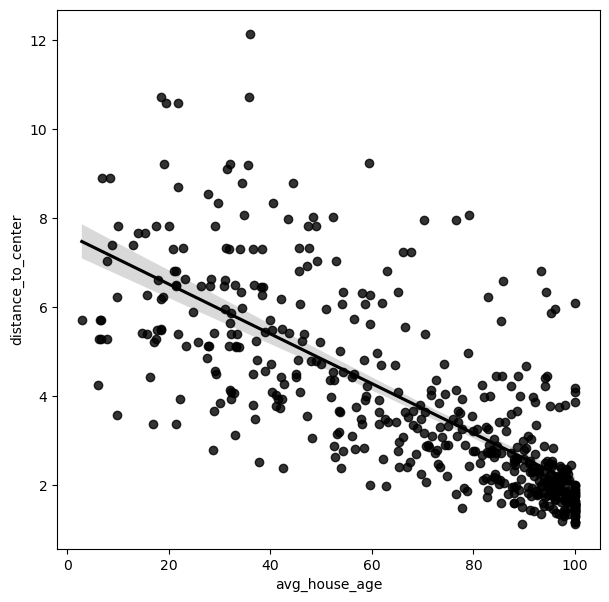

In [24]:
# Scatter Plot 5

plt.figure(figsize = (7, 7))
sns.regplot(x = 'avg_house_age', y = 'distance_to_center', data = df, color = 'black')
plt.show()

In [25]:
# Correlation Coefficient

print('The correlation between the variables is:', pearsonr(df['avg_house_age'], 
                                                     df['distance_to_center'])[0])

The correlation between the variables is: -0.7474258681640552


Analysis:

**Negative Correlation:** As the distance from the city center increases, the average age of residential properties decreases.

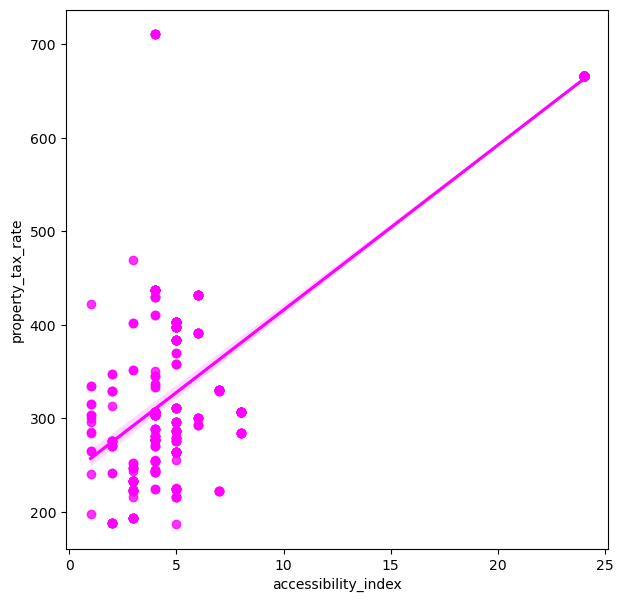

In [26]:
# Scatter Plot 6

plt.figure(figsize = (7, 7))
sns.regplot(x = 'accessibility_index', y = 'property_tax_rate', data = df, color = 'magenta')
plt.show()

In [27]:
# Correlation Coefficient
print('The correlation between the variables is:', pearsonr(df['accessibility_index'], 
                                                     df['property_tax_rate'])[0])

The correlation between the variables is: 0.9097418944674466


Analysis:

**Positive Correlation:** The correlation between the variables is very high, but no clear trend is visible between them. This may be due to outliers.

We will perform outlier treatment on the variables from the previous analysis. Subsequently, we will reassess the correlation structure after removing the outliers. Based on the univariate analysis, the histogram indicated that most observations are concentrated below 600. Therefore, we will re-plot the data after applying this filtering criterion.

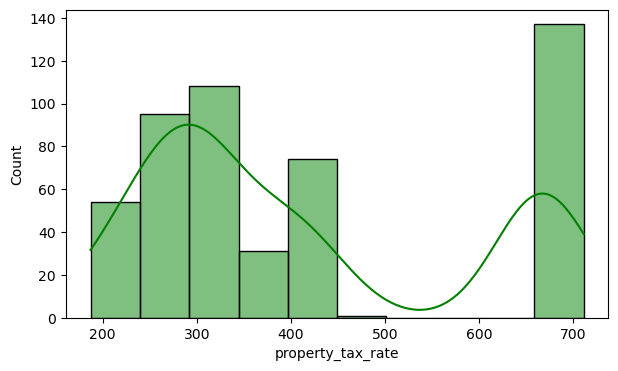

In [28]:
# Histagram plot

plt.figure(figsize = (7, 4))
sns.histplot(data = df, x = df.property_tax_rate, kde = True, color = 'green')
plt.show()

In [29]:
# Removing outliers (keeping only values below 600)

df1 = df[df['property_tax_rate'] < 600]

In [30]:
# Correlation Coefficient (Note that we did not modify the original dataset, which is why we are using df1.)

print('The correlation between the variables is:', pearsonr(df1['property_tax_rate'], 
                                                     df1['accessibility_index'])[0])

The correlation between the variables is: 0.23887638770857877


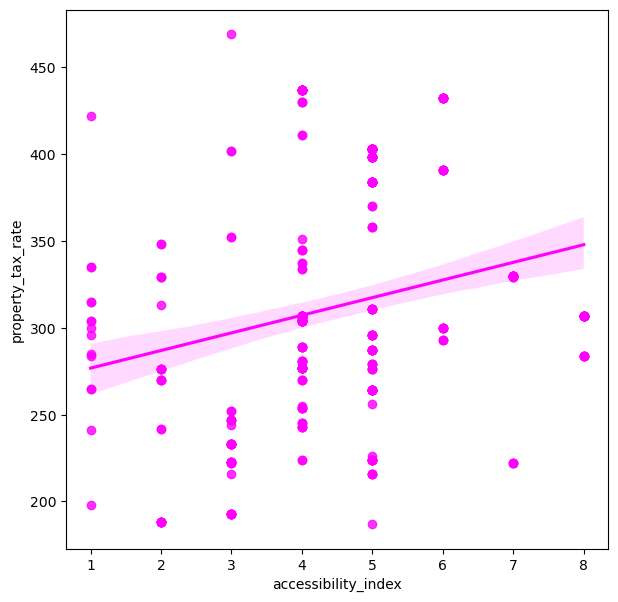

In [31]:
# Scatter Plot 6

plt.figure(figsize = (7, 7))
sns.regplot(x = 'accessibility_index', y = 'property_tax_rate', data = df1, color = 'magenta')
plt.show()

In [32]:
# Correlation Coefficient

print('The correlation between the variables is:', pearsonr(df1['property_tax_rate'], 
                                                     df1['accessibility_index'])[0])

The correlation between the variables is: 0.23887638770857877


Analysis:

- **Positive Correlation.**

- The correlation between the two variables was 0.91 before removing outliers and dropped to 0.24 after their removal.

- Therefore, the previously high correlation was driven by outliers. The tax value for some properties may be higher due to other factors.

- There does not appear to be a direct relationship between the two variables.

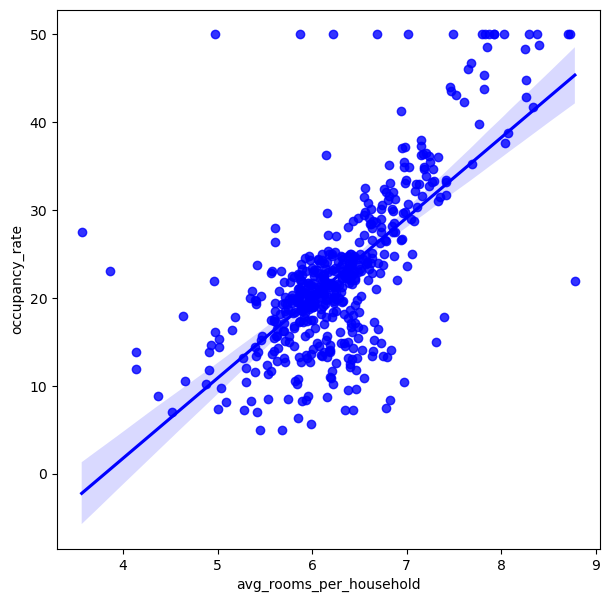

In [33]:
# Scatter Plot 7
plt.figure(figsize = (7, 7))
sns.regplot(x = 'avg_rooms_per_household', y = 'occupancy_rate', data = df, color = 'blue')
plt.show()

In [34]:
# Correlation Coefficient

print('The correlation between the variables is:', pearsonr(df['avg_rooms_per_household'], 
                                                     df['occupancy_rate'])[0])

The correlation between the variables is: 0.6964238264843787


Analysis:

- **Positive Correlation.**

- The housing occupancy rate appears to increase as the average number of rooms per dwelling rises. This is expected, as occupancy may be higher when there are more rooms.

- There are some outliers forming a horizontal line at the top of the plot, which may indicate a ceiling effect in the data.

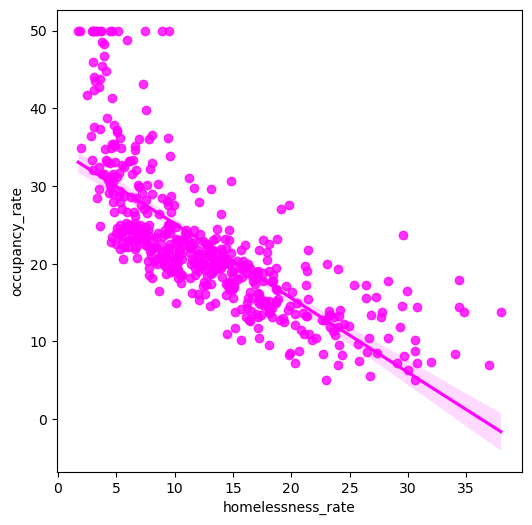

In [35]:
# Scatter Plot 8

plt.figure(figsize = (6, 6))
sns.regplot(x = 'homelessness_rate', y = 'occupancy_rate', data = df, color = 'magenta')
plt.show()

In [36]:
# Correlation Coefficient

print('The correlation between the variables is:', pearsonr(df['homelessness_rate'], 
                                                     df['occupancy_rate'])[0])

The correlation between the variables is: -0.7422362776461562


Analysis:

- **Positive Correlation.**

- Neighborhoods with a higher number of homeless individuals tend to have lower housing occupancy rates.

- There are few outliers, and the data appears to be limited to 50 observations.

### Exploratory Data Analysis Conclusion

> There are significant relationships between some independent variables, which is not desirable for a linear regression model, and decisions will need to be made. We will base these decisions on the analysis of the datasets.

## Data Wrangling

We will split the dataset into X and Y variables, and then divide the data into training and testing sets using an 80/20 split.”

In [37]:
# Splitting the variables

Y = df['occupancy_rate_log']
X = df.drop(columns = {'occupancy_rate', 'occupancy_rate_log'})

In [ ]:
# Split the datasets

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.20 , random_state = 1)

In [39]:
X_train.shape

(400, 13)

In [40]:
X_test.shape

(100, 13)

In [41]:
y_train.shape

(400,)

In [42]:
y_test.shape

(100,)

## Statistical Modeling – First Version of the Model

Here we will use the input data in its original raw state.

Do not lose sight of the objective: which factors most influence property occupancy rates?

In [43]:
# Add the constant (intercept)
# This is required by Statsmodels

X_train_const = sm.add_constant(X_train)

In [44]:
X_train_const.shape

(400, 14)

In [45]:
type(X_train_const)

pandas.core.frame.DataFrame

In [46]:
# Create first model

model_v1 = sm.OLS(y_train, X_train_const).fit()

In [47]:
# Model_v1 summary

model_v1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     occupancy_rate_log   R-squared:                       0.802
Model:                            OLS   Adj. R-squared:                  0.796
Method:                 Least Squares   F-statistic:                     120.5
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          5.52e-127
Time:                        22:39:35   Log-Likelihood:                 111.52
No. Observations:                 400   AIC:                            -195.0
Df Residuals:                     386   BIC:                            -139.2
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       4.0295      0.227     17.766      0.000       3.584       4.475
avg_rooms_per_household     0.0952      0.019      5.035      0.000       0.058       0.132
avg_house_age               0.0009      0.001      1.607      0.109      -0.000       0.002
crime_rate                 -0.0102      0.001     -7.713      0.000      -0.013      -0.008
land_ratio                  0.0015      0.001      2.372      0.018       0.000       0.003
business_ratio              0.0017      0.003      0.628      0.530      -0.004       0.007
river_proximity             0.0895      0.036      2.477      0.014       0.018       0.161
pollution_rate             -0.7708      0.167     -4.628      0.000      -1.098      -0.443
distance_to_center         -0.0462      0.009     -5.221      0.000      -0.064      -0.029
accessibility_index         0.0135      0.003      4.409      0.000       0.007       0.019
property_tax_rate          -0.0006      0.000     -3.599      0.000      -0.001      -0.000
teacher_ratio              -0.0338      0.006     -5.678      0.000      -0.046      -0.022
avg_energy_consumption      0.0002      0.000      2.048      0.041    9.67e-06       0.000
homelessness_rate          -0.0308      0.002    -13.331      0.000      -0.035      -0.026
==============================================================================
Omnibus:                       55.164   Durbin-Watson:                   1.969
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              169.106
Skew:                           0.616   Prob(JB):                     1.90e-37
Kurtosis:                       5.938   Cond. No.                     1.51e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.51e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [48]:
# Coefficients learned by the model

model_v1.params

const                      4.029452
avg_rooms_per_household    0.095247
avg_house_age              0.000948
crime_rate                -0.010173
land_ratio                 0.001451
business_ratio             0.001684
river_proximity            0.089488
pollution_rate            -0.770793
distance_to_center        -0.046237
accessibility_index        0.013476
property_tax_rate         -0.000623
teacher_ratio             -0.033816
avg_energy_consumption     0.000242
homelessness_rate         -0.030751
dtype: float64

Analysis:

- The model demonstrates strong performance, with an R² above 0.8. However, as highlighted in point 2 of the summary, there is evidence of multicollinearity among the predictors. This issue should be further investigated and addressed to ensure the reliability of the coefficient estimates.

## Checking Multicollinearity with VIF

Next, we will check multicollinearity in the training dataset. We will use the Variance Inflation Factor (VIF) to verify whether multicollinearity exists in the data.

The Variance Inflation Factor (VIF) is a measure that quantifies how much the variance of a regression estimator (coefficient) is increased due to multicollinearity in a multiple regression model. Multicollinearity occurs when there are high correlations between two or more explanatory (independent) variables in a regression model, which can make it difficult to estimate the regression coefficients accurately.

Variables with a VIF score greater than 5 will be removed or treated until all features have a VIF score below 5.

In [49]:
# Function to check VIF for all variables
def check_vif(train):
    
    # Create the dataframe
    vif = pd.DataFrame()
    
    # Fill each column
    vif["feature"] = train.columns

    # Compute VIF for each variable
    vif["VIF"] = [variance_inflation_factor(train.values, i) for i in range(len(train.columns))]
    
    return vif

In [50]:
type(X_train)

pandas.core.frame.DataFrame

In [51]:
# We are checking the VIF without the constant required by Statsmodels.

print(check_vif(X_train))

                    feature        VIF
0   avg_rooms_per_household  79.891041
1             avg_house_age  21.999229
2                crime_rate   1.986129
3                land_ratio   2.995889
4            business_ratio  14.274312
5           river_proximity   1.163134
6            pollution_rate  72.198368
7        distance_to_center  15.124267
8       accessibility_index  16.869623
9         property_tax_rate  66.888831
10            teacher_ratio  89.425493
11   avg_energy_consumption  20.530499
12        homelessness_rate  11.856588


Analysis:

- Most variables showed a very high VIF. Could the scale of the data have affected the calculation? Most likely yes. Let’s adjust this now.

## Data Standardization

In [52]:
# Create Scaler

scaler = StandardScaler()

In [53]:
# Fit and transform in Train

X_train_scaled = scaler.fit_transform(X_train)

In [54]:
X_train_scaled.shape

(400, 13)

In [55]:
# Transform in Test

X_test_scaled = scaler.transform(X_test)

In [56]:
X_test_scaled.shape

(100, 13)

## Statistical Modeling – Second Version of the Model

Here we will use standardized data (on the same scale).

In [57]:
# Adds the constant (required for models created with Statsmodels).

X_train_const = sm.add_constant(X_train_scaled)

In [58]:
type(X_train_const)

numpy.ndarray

In [59]:
X_train_const.shape

(400, 14)

In [60]:
type(y_train)

pandas.core.series.Series

In [61]:
y_train.shape

(400,)

In [62]:
# Creating the model_v2

model_v2 = sm.OLS(y_train, X_train_const).fit()

In [63]:
# statistical summary

model_v2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     occupancy_rate_log   R-squared:                       0.802
Model:                            OLS   Adj. R-squared:                  0.796
Method:                 Least Squares   F-statistic:                     120.5
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          5.52e-127
Time:                        22:39:36   Log-Likelihood:                 111.52
No. Observations:                 400   AIC:                            -195.0
Df Residuals:                     386   BIC:                            -139.2
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0436      0.009    326.592      0.000       3.025       3.062
x1             0.0668      0.013      5.035      0.000       0.041       0.093
x2             0.0269      0.017      1.607      0.109      -0.006       0.060
x3            -0.0940      0.012     -7.713      0.000      -0.118      -0.070
x4             0.0343      0.014      2.372      0.018       0.006       0.063
x5             0.0116      0.018      0.628      0.530      -0.025       0.048
x6             0.0239      0.010      2.477      0.014       0.005       0.043
x7            -0.0906      0.020     -4.628      0.000      -0.129      -0.052
x8            -0.0987      0.019     -5.221      0.000      -0.136      -0.062
x9             0.1180      0.027      4.409      0.000       0.065       0.171
x10           -0.1059      0.029     -3.599      0.000      -0.164      -0.048
x11           -0.0731      0.013     -5.678      0.000      -0.098      -0.048
x12            0.0220      0.011      2.048      0.041       0.001       0.043
x13           -0.2191      0.016    -13.331      0.000      -0.251      -0.187
==============================================================================
Omnibus:                       55.164   Durbin-Watson:                   1.969
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              169.106
Skew:                           0.616   Prob(JB):                     1.90e-37
Kurtosis:                       5.938   Cond. No.                         10.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Analysis:

- The R-squared is practically the same, indicating that the model has good performance. Let’s now check the VIF.

In [64]:
df.columns

Index(['avg_rooms_per_household', 'avg_house_age', 'crime_rate', 'land_ratio',
       'business_ratio', 'river_proximity', 'pollution_rate',
       'distance_to_center', 'accessibility_index', 'property_tax_rate',
       'teacher_ratio', 'avg_energy_consumption', 'homelessness_rate',
       'occupancy_rate', 'occupancy_rate_log'],
      dtype='object')

In [65]:
type(X_train_scaled)

numpy.ndarray

In [66]:
# Converts the NumPy array into a Pandas DataFrame (required for VIF).

df_X_train = pd.DataFrame(X_train_scaled)

In [67]:
type(df_X_train)

pandas.core.frame.DataFrame

In [68]:
print(check_vif(df_X_train))

    feature       VIF
0         0  2.028621
1         1  3.216635
2         2  1.708968
3         3  2.409812
4         4  3.920927
5         5  1.074111
6         6  4.415409
7         7  4.114200
8         8  8.242494
9         9  9.966244
10       10  1.906999
11       11  1.330456
12       12  3.109482


In [69]:
# We need a dataframe to check VIF. Let's include the name of each column to facilitate the analysis.

df_X_train = pd.DataFrame(X_train_scaled, columns = ['avg_rooms_per_household',
                                                     'avg_house_age',
                                                     'crime_rate',
                                                     'land_ratio',
                                                     'business_ratio', 
                                                     'river_proximity',
                                                     'pollution_rate',
                                                     'distance_to_center',
                                                     'accessibility_index', 
                                                     'property_tax_rate', 
                                                     'teacher_ratio',
                                                     'avg_energy_consumption', 
                                                     'homelessness_rate'])

In [70]:
print(check_vif(df_X_train))

                    feature       VIF
0   avg_rooms_per_household  2.028621
1             avg_house_age  3.216635
2                crime_rate  1.708968
3                land_ratio  2.409812
4            business_ratio  3.920927
5           river_proximity  1.074111
6            pollution_rate  4.415409
7        distance_to_center  4.114200
8       accessibility_index  8.242494
9         property_tax_rate  9.966244
10            teacher_ratio  1.906999
11   avg_energy_consumption  1.330456
12        homelessness_rate  3.109482


Analysis:

- The variables accessibility_index and property_tax_rate show a VIF greater than 5, indicating multicollinearity. We will remove these variables.

- VIF must be calculated only on the training dataset. However, variables must be removed from both the training and test sets.

In [71]:
del df_X_train["accessibility_index"]

In [72]:
del df_X_train["property_tax_rate"]

In [73]:
df_X_train.shape

(400, 11)

In [74]:
df_X_train.columns

Index(['avg_rooms_per_household', 'avg_house_age', 'crime_rate', 'land_ratio',
       'business_ratio', 'river_proximity', 'pollution_rate',
       'distance_to_center', 'teacher_ratio', 'avg_energy_consumption',
       'homelessness_rate'],
      dtype='object')

In [75]:
# We convert the test array into a test dataframe

df_X_test = pd.DataFrame(X_test_scaled, columns = ['avg_rooms_per_household',
                                                    'avg_house_age',
                                                    'crime_rate',
                                                    'land_ratio',
                                                    'business_ratio', 
                                                    'river_proximity',
                                                    'pollution_rate',
                                                    'distance_to_center',
                                                    'accessibility_index', 
                                                    'property_tax_rate', 
                                                    'teacher_ratio',
                                                    'avg_energy_consumption', 
                                                    'homelessness_rate'])

In [76]:
del df_X_test["accessibility_index"]

In [77]:
del df_X_test["property_tax_rate"]

In [78]:
df_X_test.shape

(100, 11)

In [79]:
print(check_vif(df_X_train))

                    feature       VIF
0   avg_rooms_per_household  1.944437
1             avg_house_age  3.190144
2                crime_rate  1.436394
3                land_ratio  2.250999
4            business_ratio  3.289783
5           river_proximity  1.057753
6            pollution_rate  3.815908
7        distance_to_center  4.113862
8             teacher_ratio  1.517930
9    avg_energy_consumption  1.291092
10        homelessness_rate  3.106567


Analysis:

- We were able to remove multicollinearity from the dataset, thereby satisfying one of the assumptions of linear regression.

In [80]:
# Convert the dataframe back to NumPy format.

X_train_scaled = df_X_train.to_numpy()

In [81]:
X_train_scaled.shape

(400, 11)

In [82]:
# Convert the dataframe back to NumPy format.

X_test_scaled = df_X_test.to_numpy()

In [83]:
X_test_scaled.shape

(100, 11)

## Statistical Modeling – Third Version of the Model

Here we will use the standardized data and the variables without multicollinearity.

In [84]:
# add the constant

X_train_const = sm.add_constant(X_train_scaled)

In [85]:
# Create 3rd model

model_v3 = sm.OLS(y_train, X_train_const).fit()

In [86]:
# Summary

model_v3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     occupancy_rate_log   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     134.6
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          5.03e-125
Time:                        22:39:36   Log-Likelihood:                 101.69
No. Observations:                 400   AIC:                            -179.4
Df Residuals:                     388   BIC:                            -131.5
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0436      0.010    319.489      0.000       3.025       3.062
x1             0.0768      0.013      5.784      0.000       0.051       0.103
x2             0.0213      0.017      1.251      0.212      -0.012       0.055
x3            -0.0808      0.011     -7.073      0.000      -0.103      -0.058
x4             0.0255      0.014      1.786      0.075      -0.003       0.054
x5            -0.0101      0.017     -0.584      0.560      -0.044       0.024
x6             0.0288      0.010      2.937      0.004       0.010       0.048
x7            -0.0804      0.019     -4.319      0.000      -0.117      -0.044
x8            -0.0988      0.019     -5.111      0.000      -0.137      -0.061
x9            -0.0643      0.012     -5.477      0.000      -0.087      -0.041
x10            0.0185      0.011      1.706      0.089      -0.003       0.040
x11           -0.2171      0.017    -12.929      0.000      -0.250      -0.184
==============================================================================
Omnibus:                       61.536   Durbin-Watson:                   2.016
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              210.597
Skew:                           0.655   Prob(JB):                     1.86e-46
Kurtosis:                       6.304   Cond. No.                         5.36
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In statistical modeling, the p-value is a measure of the probability that the observed results occurred by chance. It is commonly used in hypothesis testing to determine whether a given model or hypothesis is supported by the data.

In the context of a statistical modeling summary table, the p-value is typically presented as a column and reflects the probability of obtaining the observed results under the assumption that the null hypothesis is true. The null hypothesis is a statement that there is no relationship between the predictor variables and the response variable in the model.

For example, if the p-value for a given predictor variable in the statistical model summary is very small (usually less than 0.05), it indicates that there is a low probability of obtaining the observed results by chance alone, and therefore the null hypothesis can be rejected. This suggests that there is a statistically significant relationship between the predictor variable and the response variable.

On the other hand, if the p-value is large (usually greater than 0.05), it indicates that the observed results may have occurred by chance, and the null hypothesis cannot be rejected. In this case, there is not enough evidence to support the existence of a relationship between the predictor variable and the response variable.

It is important to note that the p-value is only one factor to consider when evaluating the results of a statistical model. Other factors, such as effect size and the strength of the association, should also be taken into account when interpreting the model results.

Analysis:

- The R² has slightly decreased, but the model still shows strong performance.

- Variables x2, x5, and x10 showed p-values much higher than 0.05. Therefore, they do not appear to be significant for the model and will be removed.

In [87]:
# We remove the columns at indices 1, 4, and 9 in the training set.

X_train_clean = np.delete(X_train_scaled, [1, 4, 9], axis = 1)

In [88]:
# We remove the columns at indices 1, 4, and 9 in the test set.

X_test_clean = np.delete(X_test_scaled, [1, 4, 9], axis = 1)

In [89]:
X_train_clean.shape

(400, 8)

In [90]:
X_test_clean.shape

(100, 8)

## Statistical Modelling - 4th Model version

Here we will use the standardized data, without multicollinear variables and without variables with low significance for explaining the target variable.

In [91]:
# Add the constant
X_train_const = sm.add_constant(X_train_clean)

In [92]:
# Create Model v4
model_v4 = sm.OLS(y_train, X_train_const).fit()

In [93]:
# Summary

model_v4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     occupancy_rate_log   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     183.3
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          3.17e-127
Time:                        22:39:36   Log-Likelihood:                 98.927
No. Observations:                 400   AIC:                            -179.9
Df Residuals:                     391   BIC:                            -143.9
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0436      0.010    318.514      0.000       3.025       3.062
x1             0.0796      0.013      6.157      0.000       0.054       0.105
x2            -0.0855      0.011     -7.629      0.000      -0.108      -0.063
x3             0.0223      0.014      1.573      0.116      -0.006       0.050
x4             0.0300      0.010      3.063      0.002       0.011       0.049
x5            -0.0844      0.016     -5.202      0.000      -0.116      -0.053
x6            -0.1040      0.018     -5.794      0.000      -0.139      -0.069
x7            -0.0666      0.011     -5.905      0.000      -0.089      -0.044
x8            -0.2133      0.015    -13.938      0.000      -0.243      -0.183
==============================================================================
Omnibus:                       57.577   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              186.212
Skew:                           0.627   Prob(JB):                     3.67e-41
Kurtosis:                       6.099   Cond. No.                         4.39
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Analysis:

- The R² value is almost the same, but now without multicollinear variables and irrelevant variables. We need to remove variable x3.

In [94]:
# Remove the columns at index 2 in the train set.

X_train_clean2 = np.delete(X_train_clean, [2], axis = 1)

In [95]:
# Remove the columns at index 2 in the test set.

X_test_clean2 = np.delete(X_test_clean, [2], axis = 1)

In [96]:
X_train_clean2.shape

(400, 7)

In [97]:
X_test_clean2.shape

(100, 7)

## Statistical Modelling - 5th Model version

Here we will use the standardized data, without multicollinear variables and without variables with low significance for explaining the target variable.

In [98]:
# Add the constant

X_train_const = sm.add_constant(X_train_clean2)

In [99]:
# Create Model v5

model_v5 = sm.OLS(y_train, X_train_const).fit()

In [100]:
# Summary

model_v5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     occupancy_rate_log   R-squared:                       0.788
Model:                            OLS   Adj. R-squared:                  0.784
Method:                 Least Squares   F-statistic:                     208.3
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          7.24e-128
Time:                        22:39:36   Log-Likelihood:                 97.665
No. Observations:                 400   AIC:                            -179.3
Df Residuals:                     392   BIC:                            -147.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0436      0.010    317.916      0.000       3.025       3.062
x1             0.0829      0.013      6.491      0.000       0.058       0.108
x2            -0.0827      0.011     -7.458      0.000      -0.104      -0.061
x3             0.0297      0.010      3.026      0.003       0.010       0.049
x4            -0.0838      0.016     -5.155      0.000      -0.116      -0.052
x5            -0.0889      0.015     -5.849      0.000      -0.119      -0.059
x6            -0.0715      0.011     -6.579      0.000      -0.093      -0.050
x7            -0.2131      0.015    -13.900      0.000      -0.243      -0.183
==============================================================================
Omnibus:                       61.760   Durbin-Watson:                   2.014
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              200.712
Skew:                           0.675   Prob(JB):                     2.61e-44
Kurtosis:                       6.197   Cond. No.                         3.71
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Analysis:

- The R² value is almost the same, but now without multicollinear variables and irrelevant variables.

- We have completed the statistical modeling and identified the best variables for predicting the target variable.

- Can we use the model and extract insights?  **No!** 
We still need to validate the model assumptions.

## Validation of Linear Regression Assumptions

Can we use the regression model created so far?

Yes, as long as the assumptions are validated.

**1 – Linearity**

**2 – Independence of Errors**

**3 – Homoscedasticity**

**4 – Normality of Errors**

**5 – No Multicollinearity**

We will use the latest version of the model to perform these validations.

### 1 – Linearity

One of the crucial assumptions we test when building ordinary least squares (OLS) or linear regression models is linearity in the parameters.

Linearity simply means that our dependent variable (Y) can be expressed as a linear function of the explanatory variables (X) that we choose to explain the variation in Y. Note that the term “linear regression” emphasizes the importance of the linearity assumption.

Linear regression requires the relationship between independent and dependent variables to be linear. It is also important to check for outliers, as linear regression is sensitive to extreme values. The linearity assumption can be best tested using scatter plots or by applying the linear_rainbow test.

The linear_rainbow test checks whether a regression model is linear or not. It is called “rainbow” because it splits the data into several groups using different cut points and compares the residuals across these groups. If the residuals across groups show similar variation, this suggests that the regression is linear. If the residuals show different variances, this suggests non-linearity.

To perform the linear_rainbow test using statsmodels, you can use the linear_rainbow() method.

To interpret the result, you can compare the p-value with a predefined significance level (e.g., 0.05).

- If the p-value is lower than the significance level, we reject the null hypothesis (H0). This indicates evidence of non-linearity, meaning the assumption is not satisfied.

- If the p-value is greater than the significance level, we fail to reject the null hypothesis (H0). This indicates that the relationship is likely linear and the assumption is satisfied.

In [101]:
# We will build a function to automate the validation of assumption 1.

# Function
def check_assumption_1(model_name):
    
    # Define the model
    model = model_name
    
    # Apply the linear_rainbow test
    lin_p = sms.linear_rainbow(model, frac = 0.5)[1]
    
    print(lin_p)
    
    # Initialize result as Fail
    result = "We reject the null hypothesis (H0). This indicates evidence of heteroscedasticity and that the regression is not homoscedastic. The assumption is not satisfied."
    
    # Test the result
    if lin_p > 0.05:
        result = "Success! We fail to reject the null hypothesis (H0). This indicates that the regression is likely homoscedastic and the assumption is satisfied."
        
    # Return
    return np.transpose(pd.DataFrame([[lin_p], [0.05], [result]],
                                     index = ['p-value', 'alpha', 'Result'],
                                     columns = ['Rainbow Linearity Test p-value'] ))

In [102]:
# Apply function

check_assumption_1(model_v5)

0.7311264246842837


,p-value,alpha,Result
Rainbow Linearity Test p-value,0.731126,0.05,Success! We fail to reject the null hypothesis...


Analysis:

- Success! We fail to reject the null hypothesis (H0). This indicates that the regression is likely homoscedastic and the assumption is satisfied.

### 2 – Independence of Errors

In linear regression, the assumption of independence of errors states that the errors (residuals) are independent of each other. This means that the value of one error should not be influenced by the value of any other error.

This assumption is important because it is required for accurate estimation of confidence intervals and p-values of the model parameters. If the independence assumption is violated, confidence intervals and p-values may become misleading or inaccurate.

To check whether the independence of errors assumption is satisfied, you can plot residuals versus time (if the data represents time-ordered observations) and check for any visible patterns. You can also use a statistical test, such as the Durbin-Watson test, to assess this assumption. If the independence assumption is not met, you may consider using a different regression model or including additional variables to account for error dependence.

To test this assumption, we will plot residuals against fitted values and ensure that the residuals do not form a strong pattern. They should be randomly and evenly distributed along the x-axis.

In [103]:
# Let's extract the residuals from Model_v5

residuals = model_v5.resid

In [104]:
print(residuals)

238   -0.166180
438   -0.030578
475   -0.054838
58     0.060189
380    0.166027
         ...   
255   -0.040429
72    -0.143031
396   -0.236106
235    0.007499
37    -0.097867
Length: 400, dtype: float64


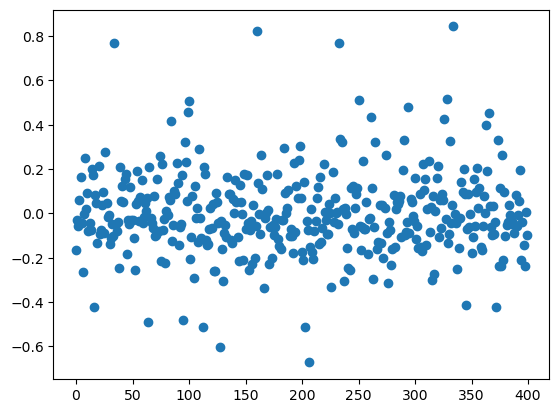

In [105]:
# Plot

plt.scatter(range(len(X_train_clean2)), residuals);

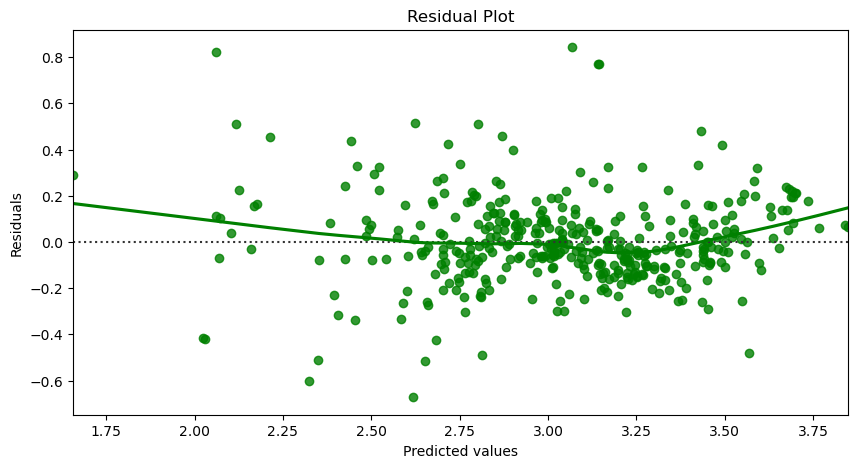

In [106]:
# Predicted values

predicted_values = model_v5.fittedvalues

# Plot

plt.figure(figsize = (10,5))
sns.residplot(x = predicted_values, y = residuals, color = "green", lowess = True)
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

**Analysis::**

- The mean of the residuals is very close to 0; therefore, the assumption regarding the residuals is satisfied. The residuals are randomly plotted around 0.

- The residuals “randomly fluctuate” around the 0 line. This suggests that there is no autocorrelation.

- The residuals form an approximately horizontal band around the 0 line. This suggests that the variances of the error terms are constant.

- No residual stands out from the basic random pattern of residuals. This suggests that there are no outliers.

The Durbin-Watson test is a statistical test used to check whether the assumption of independence of errors is being satisfied in a linear regression model. This test is especially useful when the data consists of time-ordered observations, as it can detect autocorrelation in the residuals.

To apply the Durbin-Watson test using statsmodels, you can use the durbin_watson() method. This method returns a value between 0 and 4, where values close to 0 indicate positive autocorrelation in the residuals and values close to 4 indicate negative autocorrelation in the residuals. Values close to 2 indicate no autocorrelation in the residuals.

In [107]:
# We will build a function to automate the validation of assumption 2.

# Function
def check_assumption_2(residuals):
    
    import statsmodels
    
    # Define the model
    result = statsmodels.stats.stattools.durbin_watson(residuals)
    
    print('Test result:', result)
    
    # Interpret the result
    if result < 1.9:
        print("There is evidence of positive autocorrelation in the residuals! Assumption not satisfied!")
    elif result > 2.1:
        print("There is evidence of negative autocorrelation in the residuals! Assumption not satisfied!")
    else:
        print("There is no evidence of autocorrelation in the residuals! Assumption satisfied!")

In [108]:
check_assumption_2(residuals)

Test result: 2.0139604390878976
There is no evidence of autocorrelation in the residuals! Assumption satisfied!


### 3 – Homoscedasticity

The assumption of homoscedasticity (meaning “same variance”) is fundamental in linear regression models. Homoscedasticity describes a situation in which the error term (i.e., the “noise” or random disturbance in the relationship between the independent variables and the dependent variable) is the same across all values of the independent variables.

Heteroscedasticity (the violation of homoscedasticity) occurs when the size of the error term differs across values of an independent variable. The impact of violating the homoscedasticity assumption depends on the degree of heteroscedasticity, increasing as heteroscedasticity becomes more severe.

**Homoscedasticity:** If the residuals are symmetrically distributed along the regression line, the data is considered homoscedastic (i.e., the variability is constant across values of the explanatory variable).

**Heteroscedasticity:** If the residuals are not symmetrically distributed along the regression line, the data is considered heteroscedastic. In this case, the residuals may display a funnel shape or any other non-symmetric pattern.

**Summary:**

Homoscedasticity is the property of a data distribution in which variability remains constant across all levels of a variable. In other words, homoscedasticity occurs when the data exhibits constant variance with respect to a given variable. This is different from heteroscedasticity, which occurs when the variability differs across levels of the variable.

Homoscedasticity is important in statistical analysis because many statistical tests assume that the data is homoscedastic. If the data is not homoscedastic, test results may be inaccurate or misleading.

We will use the **Goldfeld–Quandt test** to test the following hypothesis with α = 0.05:

- **Null hypothesis (H0):** There is evidence of heteroscedasticity (the regression is not homoscedastic).

- **Alternative hypothesis (H1):** There is no evidence of heteroscedasticity (the regression is likely homoscedastic).

Our goal is to reject the null hypothesis.

The Goldfeld–Quandt test checks whether a linear regression is homoscedastic or heteroscedastic. It is performed by splitting the data into two groups and comparing the residuals of both groups. If the residuals have similar variances, this suggests homoscedasticity. If the variances differ, this suggests heteroscedasticity.

To perform the Goldfeld–Quandt test using statsmodels, you can use the het_goldfeldquandt() method.

To interpret the result, compare the p-value with a predefined significance level (e.g., 0.05):

If the p-value is lower than the significance level, we reject H0. This indicates evidence of heteroscedasticity, meaning the regression is not homoscedastic.
If the p-value is greater than the significance level, we fail to reject H0. This indicates that the regression is likely homoscedastic and the assumption is satisfied.

The issue heteroscedasticity presents for regression models is straightforward. Ordinary Least Squares (OLS) regression seeks to minimize residuals and produce the smallest possible standard errors. By definition, OLS assigns equal weight to all observations, but when heteroscedasticity is present, observations with larger disturbances exert more influence than others. In such cases, weighted least squares regression would be more appropriate, as it reduces the impact of observations with higher variance.

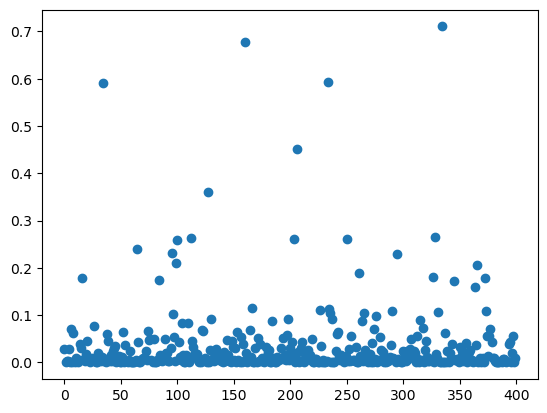

In [109]:
# Residuals

residuals = model_v5.resid

# Plot

plt.scatter(range(len(X_train_clean2)),np.square(residuals));

Since the plot does not show any pattern, we can conclude that there is no heteroscedasticity. However, we will apply a statistical test.

In [110]:
# Function
def check_assumption_3(y, x):
    
    # Statistics
    statistics = ["F statistic", "p-value"]
    
    # Test
    goldfeld_quandt_test = sms.het_goldfeldquandt(y, x)
    
    result = lzip(statistics, goldfeld_quandt_test)
    
    pval = result[1][1]
    
    if pval < 0.05:
        print("There is evidence of heteroscedasticity (the regression is not homoscedastic), and we reject H0. Assumption not satisfied!")
    else:
        print("There is no evidence of heteroscedasticity (the regression is likely homoscedastic). We fail to reject H0. Assumption satisfied!")

In [111]:
# Apply Function

check_assumption_3(y_train, X_train_clean2)

There is no evidence of heteroscedasticity (the regression is likely homoscedastic). We fail to reject H0. Assumption satisfied!


Analysis:

There is no evidence of heteroscedasticity (the regression is likely homoscedastic). We fail to reject the null hypothesis (H0). Assumption satisfied!

### 4 - Normality of Errors

Normality of error terms. The residuals should be normally distributed.

This assumption can be better assessed using a histogram or a Q-Q plot.

In linear regression, the assumption of normality of residuals is the assumption that the regression residuals (errors) follow a normal distribution. This means that the residuals should have a mean of zero and constant variance.

This assumption is important because some statistical tests and parameter estimation methods assume that the residuals follow a normal distribution. If the residuals are not normally distributed, the results of these tests and methods may be inaccurate or misleading.

To check whether the residuals follow a normal distribution, you can plot a residual graph and visually inspect whether they appear normally distributed. You can also use a normality test, such as the Shapiro–Wilk test, to verify this assumption. If the residuals are not normally distributed, you may consider transforming the data or using a different regression model.

In [112]:
# Residuals

residuals = model_v5.resid

<Axes: ylabel='Count'>

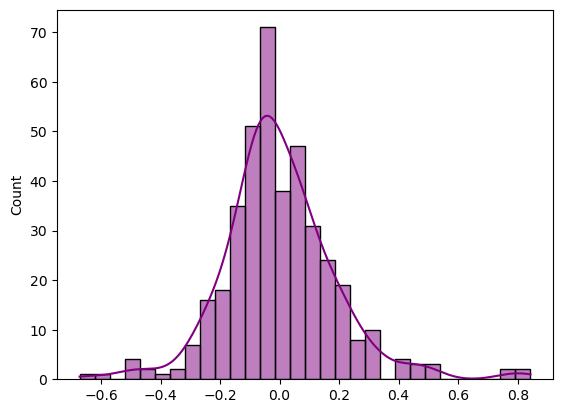

In [113]:
# Residuals histogram

sns.histplot(residuals, kde = True, color = 'purple')

Let’s create a Q-Q plot.

A Q-Q (quantile-quantile) plot is a graph used to compare two data distributions. It is called “Q-Q” because it compares the quantiles of the two distributions. Quantiles are values that divide the data into equal parts. For example, the first quartile is the value that separates the lowest quarter of the data from the remaining three quarters.

To interpret a Q-Q plot, you should observe whether the points follow a diagonal line. If the points follow a diagonal line, this indicates that the two distributions are similar. If the points do not follow a diagonal line, this indicates that the distributions are different.

A Q-Q plot is useful for checking whether the data follows a specific distribution, such as the normal distribution. If the data is normally distributed, the points in the Q-Q plot should follow a diagonal line. If they do not, this may indicate that the data is not normally distributed.

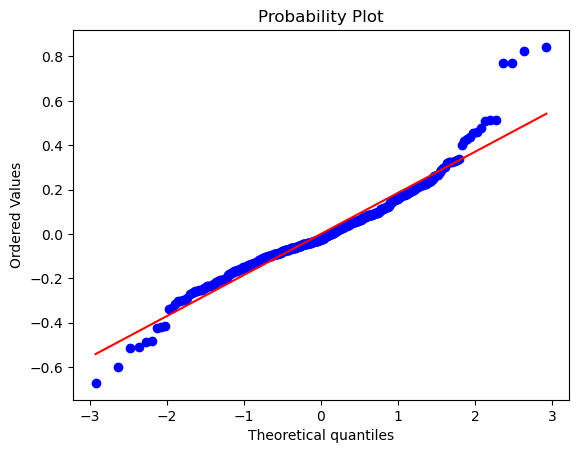

In [114]:
# QQ Plot

stats.probplot(residuals, dist = "norm", plot = pylab)
plt.show()

**Analysis:**

The residuals approximately follow a normal distribution. The assumption appears to be satisfied. We will apply the Shapiro–Wilk test to the residuals to confirm this.

To interpret the test result, you can compare the p-value with a predefined significance level (e.g., 0.05).

- If the p-value is lower than the significance level, we reject H0. This indicates evidence that the residuals are not normally distributed.

- If the p-value is greater than the significance level, we fail to reject H0. This indicates that the residuals are normally distributed.

In [115]:
# Function

def check_assumption_4(residuals):
    
    from scipy.stats import shapiro
    
    # Apply the test
    result = shapiro(residuals)
    
    # Extract p-value
    pval = result.pvalue
    
    print('p-value =', pval)
    
    if pval < 0.05:
        print("We reject H0. This indicates evidence that the residuals are not normally distributed!")
    else:
        print("We fail to reject H0. This indicates that the residuals are normally distributed. Assumption satisfied!")

In [116]:
check_assumption_4(residuals)

p-value = 1.262533272372579e-10
We reject H0. This indicates evidence that the residuals are not normally distributed!


**Analysis:**

The residuals did not pass the normality test. The deviation is likely small, but this assumption has not been satisfied.

**Notes:**

1- Neither the dependent nor the independent variables need to be normally distributed. In fact, they can follow any type of distribution. The normality assumption applies to the distribution of the errors (residuals).

2- Sometimes, non-normality of residuals indicates the presence of outliers. If this is the case, the outliers should be addressed first.

3- Applying transformations may solve the issue, but it has consequences, as the interpretation of coefficients changes when variables are transformed.

4- This does not mean that the linear model is completely useless. However, it does indicate that the model does not fully or correctly explain the data. At this point, one must decide whether the model is “good enough” or not.

5- Overfitted models may also produce non-normal residuals.

Ideally, one should go back, further refine the data and/or the model, and recheck the assumptions. However, on the other hand, some articles and professionals presents an interesting discussion and argues that the t-test and ordinary least squares linear regression do not require a normal distribution assumption when the sample size is sufficiently large (big data).

### 5 - Multicollinearity

In [117]:
# Function to check VIF for all variables

def check_assumption_5(train):
    
    # Create the dataframe
    vif = pd.DataFrame()
    
    # Fill each column
    vif["feature"] = train.columns

    # Calculate VIF for each variable
    vif["VIF"] = [variance_inflation_factor(train.values, i) for i in range(len(train.columns))]
    
    return vif

In [118]:
print(check_assumption_5(df_X_train))

                    feature       VIF
0   avg_rooms_per_household  1.944437
1             avg_house_age  3.190144
2                crime_rate  1.436394
3                land_ratio  2.250999
4            business_ratio  3.289783
5           river_proximity  1.057753
6            pollution_rate  3.815908
7        distance_to_center  4.113862
8             teacher_ratio  1.517930
9    avg_energy_consumption  1.291092
10        homelessness_rate  3.106567


**Analysis**:

There is no multicollinearity in the data. Assumption satisfied.

## Conclusion

Our model satisfies almost all assumptions. Ideally, we would go back and try to refine the model until all assumptions are fully met, or consider whether the model is good enough.

We will consider the model good enough for our purpose, as the plots showed that we are very close to normality of the residuals.

Now we will interpret the results and present our conclusions.

In [119]:
# Coefficients (what the model learned)

model_v5.params

const    3.043647
x1       0.082909
x2      -0.082661
x3       0.029659
x4      -0.083773
x5      -0.088921
x6      -0.071510
x7      -0.213070
dtype: float64

In [120]:
# Let's create a dataframe with the Coefficients

df3 = pd.DataFrame(model_v5.params)

In [121]:
df3

,0
const,3.043647
x1,0.082909
x2,-0.082661
x3,0.029659
x4,-0.083773
x5,-0.088921
x6,-0.071510
x7,-0.213070


In [122]:
# List of column names with variable names

columnsdf = ['const', 
           'avg_rooms_per_household',
           'crime_rate',
           'river_proximity',
           'pollution_rate',
           'distance_to_center',
           'teacher_rate',
           'homelessness_rate']

In [123]:
# Pivot table

pivot_df = pd.pivot_table(df3, columns = columnsdf).reset_index()

In [124]:
pivot_df

,index,avg_rooms_per_household,const,crime_rate,distance_to_center,homelessness_rate,pollution_rate,river_proximity,teacher_rate
0,0,0.082909,3.043647,-0.082661,-0.088921,-0.21307,-0.083773,0.029659,-0.07151


The target variable is the occupancy rate! Remember that.

What does the coefficient mean? The sign of a linear regression coefficient indicates whether there is a positive or negative relationship between each independent variable and the dependent variable. A positive coefficient indicates that as the value of the independent variable increases, the average value of the dependent variable also tends to increase. A negative coefficient suggests that as the independent variable increases, the dependent variable tends to decrease.

The value of the coefficient represents how much the mean of the dependent variable changes given a one-unit change in the independent variable, while keeping the other variables in the model constant. This “holding other variables constant” property is crucial because it allows us to evaluate the effect of each variable in isolation from the others.

The linear regression coefficients in your statistical output are estimates of the true population parameters. To obtain unbiased coefficient estimates with minimum variance and to be able to trust the p-values, your model must satisfy the classical assumptions of OLS linear regression.

Data Scientists consider linear regression coefficients to be an unstandardized effect size because they indicate the strength of the relationship between variables using values that retain the natural units of the dependent variable. Effect sizes help us understand the practical importance of the findings.

The regression model is a linear model, where each coefficient represents the expected change in the dependent variable for a one-unit change in the corresponding independent variable, while holding all other variables constant.

Here is the interpretation of each coefficient:

**const (3.043647):** This is the model intercept. It represents the expected value of the dependent variable when all independent variables are equal to zero. In practice, this may or may not have a meaningful interpretation, depending on whether it makes sense for all independent variables to be zero.

**distance_to_center (-0.088921):** For each one-unit increase in distance to the center, the dependent variable is expected to decrease by 0.088921 units. This suggests a negative relationship between distance from the center and the dependent variable.

**vavg_rooms_per_household (0.082909):** A one-unit increase in the average number of rooms per household is associated with an increase of 0.082909 units in the dependent variable. This indicates a positive relationship, suggesting that homes with more rooms may have a higher value.

**river_in_neighborhood (0.029659):** This coefficient indicates that the presence of a river in the neighborhood is associated with an increase of 0.029659 units in the dependent variable. Since river_in_neighborhood is a binary variable (0 or 1), having a river in the neighborhood increases the dependent variable by this amount.

**crime_rate (-0.082661):** For each one-unit increase in the crime rate, the dependent variable is expected to decrease by 0.082661 units. This suggests a negative relationship, where higher crime reduces the value of the dependent variable.

**homelessness_rate (-0.21307):** A one-unit increase in the homelessness rate is associated with a decrease of 0.21307 units in the dependent variable, indicating a strong negative relationship.

**pollution_rate (-0.083773):** A one-unit increase in the pollution rate is associated with a decrease of 0.083773 units in the dependent variable, suggesting that pollution has a negative impact.

**teacher_rate (-0.07151):** For each one-unit increase in the teacher rate, the dependent variable is expected to decrease by 0.07151 units. This result is somewhat counterintuitive, as we would typically expect a positive relationship between education quality/availability and the dependent variable. This interpretation may require a more detailed examination of the context or how the variable "teacher_rate" was measured or defined in the model.

Each coefficient provides insights into how the independent variables influence the dependent variable. However, it is also important to consider the statistical significance of each coefficient to determine whether the observed relationships are statistically meaningful.

### Most Relevant Variables

In [125]:
# Summary

model_v5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     occupancy_rate_log   R-squared:                       0.788
Model:                            OLS   Adj. R-squared:                  0.784
Method:                 Least Squares   F-statistic:                     208.3
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          7.24e-128
Time:                        22:39:38   Log-Likelihood:                 97.665
No. Observations:                 400   AIC:                            -179.3
Df Residuals:                     392   BIC:                            -147.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0436      0.010    317.916      0.000       3.025       3.062
x1             0.0829      0.013      6.491      0.000       0.058       0.108
x2            -0.0827      0.011     -7.458      0.000      -0.104      -0.061
x3             0.0297      0.010      3.026      0.003       0.010       0.049
x4            -0.0838      0.016     -5.155      0.000      -0.116      -0.052
x5            -0.0889      0.015     -5.849      0.000      -0.119      -0.059
x6            -0.0715      0.011     -6.579      0.000      -0.093      -0.050
x7            -0.2131      0.015    -13.900      0.000      -0.243      -0.183
==============================================================================
Omnibus:                       61.760   Durbin-Watson:                   2.014
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              200.712
Skew:                           0.675   Prob(JB):                     2.61e-44
Kurtosis:                       6.197   Cond. No.                         3.71
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

To check the most relevant variables for predicting the target variable, "occupancy_rate_log", in a linear regression model, you can consider the following aspects from the model summary:

1. Coefficients (coef) and Their Significance (P>|t|):

Coefficients (coef): Indicate the expected effect on the dependent variable (occupancy_rate_log) for a one-unit change in the independent variable, while holding the others constant. Larger values (in absolute magnitude) suggest a stronger impact.

P>|t| (p-value): Provides the probability that the coefficient is equal to zero (no relationship). A value below 0.05 is commonly considered statistically significant, indicating that there is sufficient evidence to conclude that a relationship exists between the independent variable and the dependent variable.

2. Confidence Intervals ([0.025 0.975]):

Confidence intervals show the range within which the true coefficient is expected to lie with 95% confidence. Variables whose intervals do not include 0 have a statistically significant relationship with the dependent variable.

Evaluating Variable Relevance:

Variables with low p-values (< 0.05) are statistically significant and considered relevant for the model.

In our case, all variables, including x1 to x7, are statistically significant for predicting occupancy_rate_log, since all p-values are below 0.05.

Coefficient magnitude: Relevance can also be assessed by the magnitude of the coefficients (ignoring the sign). For example, x7 (-0.2131) has a greater impact on occupancy_rate_log than the other variables, given the size of its coefficient.



## Answering the Business Question:

Based on the criteria above, we can determine that all variables (x1 to x7) are relevant to the model. These variables correspond to:

- avg_rooms_per_household
- crime_rate
- river_in_neighborhood
- pollution_rate
- distance_to_center
- teacher_rate
- homelessness_rate

These variables are key determinants in explaining the occupancy rate, according to the analysis of the provided data.